In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt
from vrAnalysis.sessions import B2Session
from vrAnalysis.helpers.plotting import save_figure
from vrAnalysis.helpers import edge2center
from vrAnalysis.database import get_database
from dimensionality_manuscript.figure_scripts.figure1 import (
    example_placefield,
    example_r2_placefield,
    example_traversal,
    stacked_raster_plot,
)
from dimensionality_manuscript.configs import PFPredQualityConfig
from dimensionality_manuscript import ResultsStore, ResultsAggregator
from dimensionality_manuscript.registry import RegistryPaths

sessiondb = get_database("vrSessions")
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
cfg = PFPredQualityConfig()
store = ResultsStore()
results = ResultsAggregator(cfg, store, sessions)

from syd import make_viewer
from matplotlib.lines import Line2D
from dimensionality_manuscript.configs import BehaviorSpeedEnvConfig
from dimensionality_manuscript.configs.behavior_speed_env import (
    ENV_REWARD_MAP,
    ENV_SLOTS,
    REFERENCE_ENV_LENGTH_CM,
    WINDOW_FRACTION,
)

bse_cfg = BehaviorSpeedEnvConfig()
bse_results = ResultsAggregator(bse_cfg, store, sessions)

In [2]:
registry_paths = RegistryPaths()
figure_path = registry_paths.figure_path / "figure1"
if not figure_path.exists():
    figure_path.mkdir(parents=True, exist_ok=True)

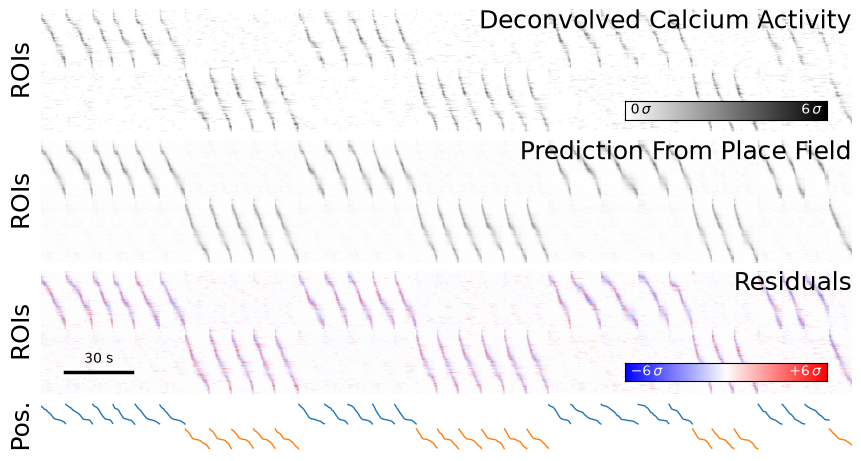

In [9]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "sigrebase"
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

return_syd_viewer = False
fig = stacked_raster_plot(
    session, 
    prediction_from="placefield", 
    figsize=(8.5, 4.5),
    xslice=slice(2835, 5000),
    show_position=True,
    position_height=0.4,
    show_zero_sigma=True,
    show_scalebar=True,
    scalebar_seconds=30,
    return_syd_viewer=return_syd_viewer,
)

if return_syd_viewer:
    fig.show()

else:
    plt.show()

    save_plot = True
    if save_plot:
        save_figure(fig, figure_path / "stacked_raster_plot")

c:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\site-packages\syd\support.py:162: ParameterUpdateWarning: Warning updating SelectionParameter parameter 'roi': Value 0 not in options, setting to first option (96)
  warn(ParameterUpdateWarning(parameter_name, parameter_type, message))


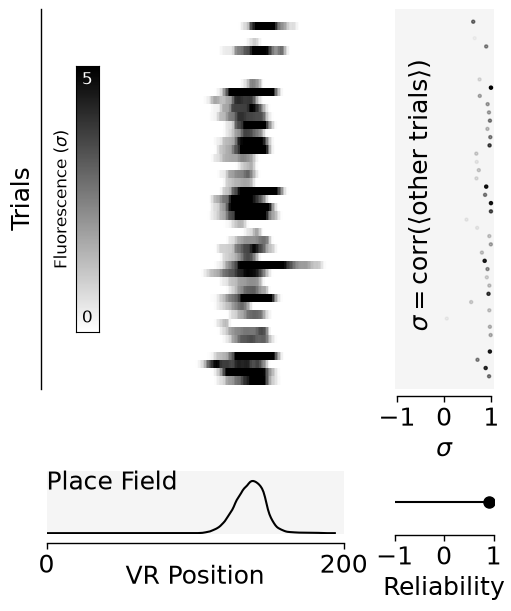

In [11]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "sigrebase"
idx_roi = {
    "oasis": 96,
    "sigrebase": 180,
}[spks_type]
idx_env = 0
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

use_viewer = False
if use_viewer:
    viewer = example_placefield(session, idx_roi, idx_env, return_syd_viewer=True)
    viewer.show()

else:
    fig = example_placefield(session, idx_roi, idx_env)

    save_plot = True
    if save_plot: 
        figure_name = f"example_placefield_{mouse_name}_{date}_{session_id}_{spks_type}_{idx_roi}_{idx_env}"
        save_figure(fig, figure_path / f"{figure_name}.png")

c:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\site-packages\syd\support.py:162: ParameterUpdateWarning: Warning updating SelectionParameter parameter 'roi': Value 0 not in options, setting to first option (96)
  warn(ParameterUpdateWarning(parameter_name, parameter_type, message))


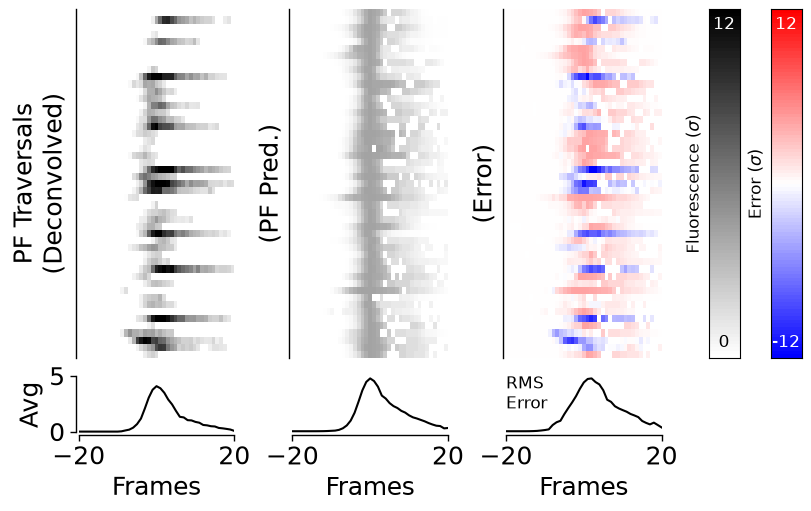

In [13]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "sigrebase"
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

idx_roi = 180 #96 was original oasis one
idx_env = 0
fig = example_traversal(session, idx_roi, idx_env)

save_plot = True
if save_plot: 
    figure_name = f"example_trajectory_{mouse_name}_{date}_{session_id}_{spks_type}_{idx_roi}_{idx_env}"
    save_figure(fig, figure_path / f"{figure_name}.png")

In [ ]:
mouse_name = "ATL027"
date = "2023-07-27"
session_id = "701"
spks_type = "sigrebase"
idx_roi = {
    "oasis": 96,
    "sigrebase": 180,
}[spks_type]
idx_env = 0
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

return_syd_viewer = True
fig = example_r2_placefield(
    results, 
    session, 
    idx_roi, 
    idx_env, 
    cloud_style="scatter",
    cloud_alpha=0.08,
    r2_ylim=(-0.05, 0.35),
    return_syd_viewer=return_syd_viewer
)
if return_syd_viewer:
    fig.show()

else:
    plt.show()

    save_plot = True
    if save_plot: 
        figure_name = f"example_r2_placefield_{mouse_name}_{date}_{session_id}_{spks_type}_{idx_roi}_{idx_env}"
        save_figure(fig, figure_path / f"{figure_name}.png")

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)


C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\figure_scripts\figure1.py:716: RuntimeWarning: Mean of empty slice
  self.dist_centers = frac_centers * REFERENCE_ENV_LENGTH_CM


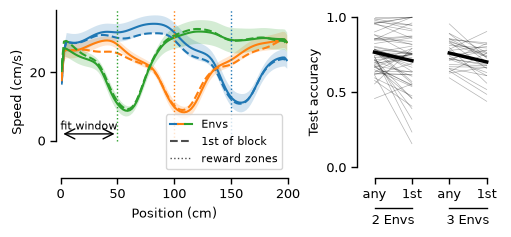

In [43]:
from dimensionality_manuscript.figure_scripts.figure1 import mouse_speed_by_environment

return_syd_viewer = True
plt.close('all')
fig = mouse_speed_by_environment(
    bse_results,
    linewidth_average=1.5,
    figsize=(5.0, 2.25),
    return_syd_viewer = return_syd_viewer,
)
if return_syd_viewer:
    fig.show()
else:
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "speed_by_environment")

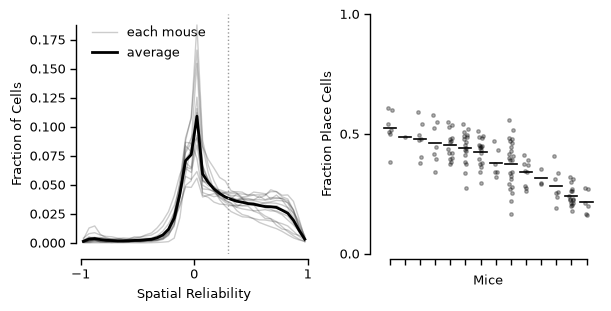

In [40]:
from dimensionality_manuscript.figure_scripts.figure1 import placefield_reliability

return_syd_viewer = True
plt.close('all')
fig = placefield_reliability(
    results,
    swarm_mode="by_mouse",
    beewidth=0.15,
    hist_alpha=0.2,
    return_syd_viewer = return_syd_viewer,
)
if return_syd_viewer:
    fig.show()
else:
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "placefield_reliability_overall")

## Decoding environment from pre-reward speed

`BehaviorSpeedEnvConfig` asks whether the speed profile *before the reward zone* reveals
which environment the mouse is in. Because the window stops short of every reward zone,
any environment information there is visually driven.

One pre-reward window (the first 25% of track, stopping at env 4's reward so all
environments stay in) x two splits (`random` = stratified 50/50; `block` = train on
later trials, test on the **first trial of each block**, i.e. immediate recognition on
entry).

`chance` is the **majority-class baseline**, not 1/n_classes, so it sits above 0.5
whenever the classes are unbalanced. It differs sharply between 2- and 3-environment
sessions (0.55 vs 0.42), so the bars are split by session environment count -- pooling
them would average two different baselines into a meaningless number. Env-indexed results
sit on the canonical `ENV_SLOTS` axis, so averaging across sessions/mice never mixes
environments.


In [10]:
ENV_COLORS = {1: "tab:blue", 3: "tab:orange", 4: "tab:green"}


def bse_plot(state):
    data, _ = bse_viewer.get_result(state)
    filtered = state["filter_by_ses_or_mouse"]

    curves_all = data["speed_curve_all"]
    curves_first = data["speed_curve_first"]
    frac = data["dist_fraction_centers"]
    if not filtered:
        # Axis 0 is sessions (or mice). Safe to pool: results are on the canonical
        # ENV_SLOTS axis, so column j is always the same environment.
        curves_all = np.nanmean(curves_all, axis=0)
        curves_first = np.nanmean(curves_first, axis=0)
        frac = np.nanmean(frac, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), width_ratios=[1.35, 1])

    # --- speed curves ---
    ax = axes[0]
    ax.axvspan(0, WINDOW_FRACTION, color="k", alpha=0.04)
    ax.axvline(WINDOW_FRACTION, color="k", lw=0.8, ls=":")
    ax.text(WINDOW_FRACTION - 0.005, 0.99, "window", transform=ax.get_xaxis_transform(), ha="right", va="top", fontsize=7, color="0.4")

    for j, env in enumerate(ENV_SLOTS):
        color = ENV_COLORS.get(env, f"C{j}")
        ax.plot(frac, curves_all[j], color=color, lw=1.8)
        ax.plot(frac, curves_first[j], color=color, lw=1.2, ls="--", alpha=0.9)
        ax.axvline(ENV_REWARD_MAP[env] / REFERENCE_ENV_LENGTH_CM, color=color, lw=1.0, alpha=0.45)

    handles = [Line2D([], [], color=ENV_COLORS[e], lw=1.8, label=f"env {e}") for e in ENV_SLOTS]
    handles += [
        Line2D([], [], color="0.3", lw=1.8, label="all trials"),
        Line2D([], [], color="0.3", lw=1.2, ls="--", label="1st of block"),
    ]
    ax.legend(handles=handles, fontsize=7, ncol=5, loc="lower center", framealpha=0.9, borderpad=0.3)
    ax.set_xlabel("position (fraction of track)")
    ax.set_ylabel("speed (cm/s)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, None)
    who = state["session_id"] if (filtered and state["view_by"] == "session") else (state["mouse"] if filtered else "all mice")
    ax.set_title(f"speed vs position — {who}\nshaded = decoder input, vlines = reward onset", fontsize=9)

    # --- decoding accuracy, split by session environment count ---
    # Always per-session: a mouse can mix 2- and 3-environment sessions, so mouse-averaging
    # would destroy the grouping. Chance is the majority-class baseline and differs a lot
    # between the two groups, so pooling them blends two different baselines.
    param_kwargs = {k: state[k] for k in ("num_bins", "regularization", "speed_threshold")}
    per_session, _ = bse_results.sel(return_param_sizes=True, avg_by_mouse=False, **param_kwargs)
    n_envs = np.sum(per_session["n_trials_per_env"] > 0, axis=1)

    ax = axes[1]
    splits = ("random", "block")
    groups = [(2, "tab:cyan"), (3, "tab:red")]
    rng = np.random.default_rng(0)
    sel_idx = bse_results.session_ids.index(state["session_id"]) if state["session_id"] in bse_results.session_ids else None

    for i, split in enumerate(splits):
        acc = per_session[f"acc_test_{split}"]
        chance = per_session[f"chance_{split}"]
        for (n_env, color), offset in zip(groups, (-0.2, 0.2)):
            m = (n_envs == n_env) & np.isfinite(acc)
            x = i + offset
            if not m.any():
                continue
            ax.bar(x, np.nanmean(acc[m]), width=0.36, color=color, alpha=0.55, zorder=0)
            ax.hlines(np.nanmean(chance[m]), x - 0.18, x + 0.18, color="k", ls="--", lw=1.2, zorder=3)
            ax.scatter(x + rng.uniform(-0.07, 0.07, m.sum()), acc[m], s=5, color="0.3", alpha=0.5, zorder=2)
            ax.text(x, 0.02, f"{int(m.sum())}", ha="center", fontsize=6, color="0.3")
            if sel_idx is not None and m[sel_idx]:
                ax.scatter(x, acc[sel_idx], s=45, marker="*", color="yellow", edgecolor="k", lw=0.5, zorder=4)

    handles = [Line2D([], [], color=c, lw=6, alpha=0.55, label=f"{n}-env sessions") for n, c in groups]
    handles.append(Line2D([], [], color="k", ls="--", lw=1.2, label="chance (majority class)"))
    ax.legend(handles=handles, fontsize=6.5, loc="upper center", ncol=3, frameon=False)
    ax.set_xticks(np.arange(len(splits)))
    ax.set_xticklabels(list(splits), fontsize=8)
    ax.set_ylabel("test accuracy")
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_ylim(0, 1.32)  # headroom for the legend; accuracy tops out at 1.0
    ax.set_title("decode env from pre-reward speed (per session)\nstar = selected session", fontsize=9)

    fig.tight_layout()
    return fig


bse_viewer = make_viewer(bse_plot)
bse_cfg.build_syd(bse_viewer, bse_results)
bse_viewer.show()


C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)
